# Notebook 5 — Classification avec CIFAR-10

Chargement, normalisation et encodage des labels du dataset CIFAR-10.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

## 1. Chargement du dataset

In [2]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print(f"X_train : {X_train.shape}, dtype={X_train.dtype}")
print(f"X_test  : {X_test.shape},  dtype={X_test.dtype}")
print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")

c:\indusense\.venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


X_train : (50000, 32, 32, 3), dtype=uint8
X_test  : (10000, 32, 32, 3),  dtype=uint8
y_train : (50000, 1)
y_test  : (10000, 1)


### 1.1 Grille d'images étiquetées

4 exemples par classe (images brutes `uint8` avant normalisation).

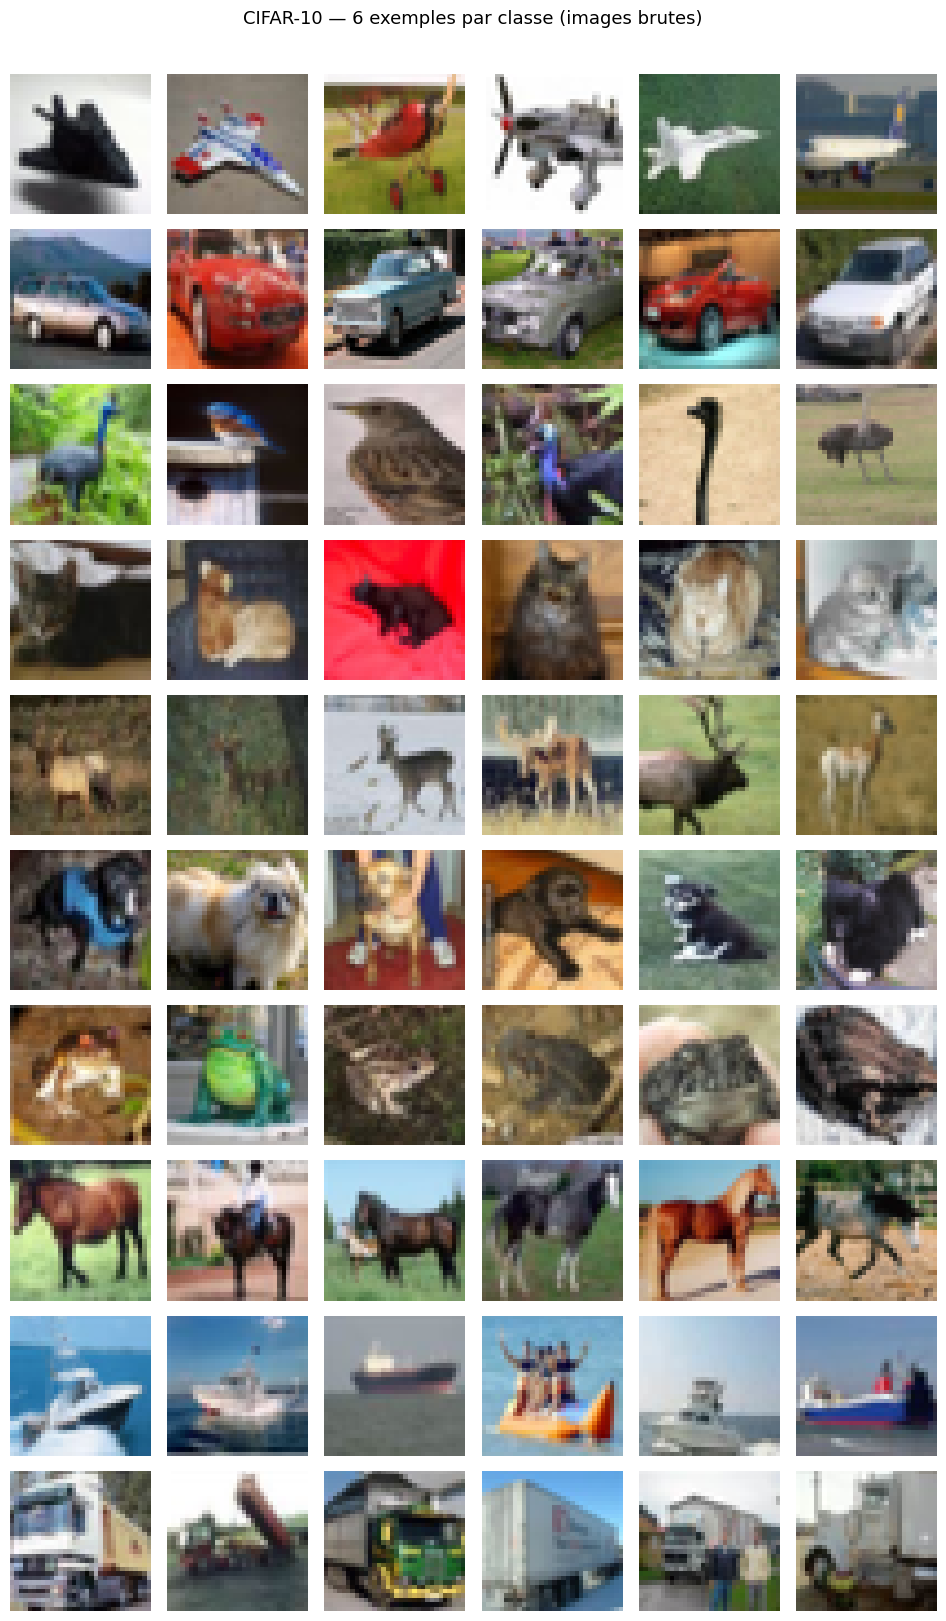

In [3]:
N_COLS = 6  # exemples par classe
fig, axes = plt.subplots(10, N_COLS, figsize=(N_COLS * 1.6, 10 * 1.6))

for cls_idx, cls_name in enumerate(CLASS_NAMES):
    indices = np.where(y_train.flatten() == cls_idx)[0][:N_COLS]
    for col, img_idx in enumerate(indices):
        ax = axes[cls_idx, col]
        ax.imshow(X_train[img_idx])
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(cls_name, fontsize=10, rotation=0,
                          labelpad=45, va='center')

plt.suptitle("CIFAR-10 — 6 exemples par classe (images brutes)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 1.2 Équilibre des classes

Un dataset déséquilibré biaise l'entraînement vers les classes majoritaires. On vérifie ici la distribution de `y_train` et `y_test`.

Classe            Train     Test   % train
------------------------------------------
airplane           5000     1000     10.0%
automobile         5000     1000     10.0%
bird               5000     1000     10.0%
cat                5000     1000     10.0%
deer               5000     1000     10.0%
dog                5000     1000     10.0%
frog               5000     1000     10.0%
horse              5000     1000     10.0%
ship               5000     1000     10.0%
truck              5000     1000     10.0%
------------------------------------------
TOTAL             50000    10000    100.0%


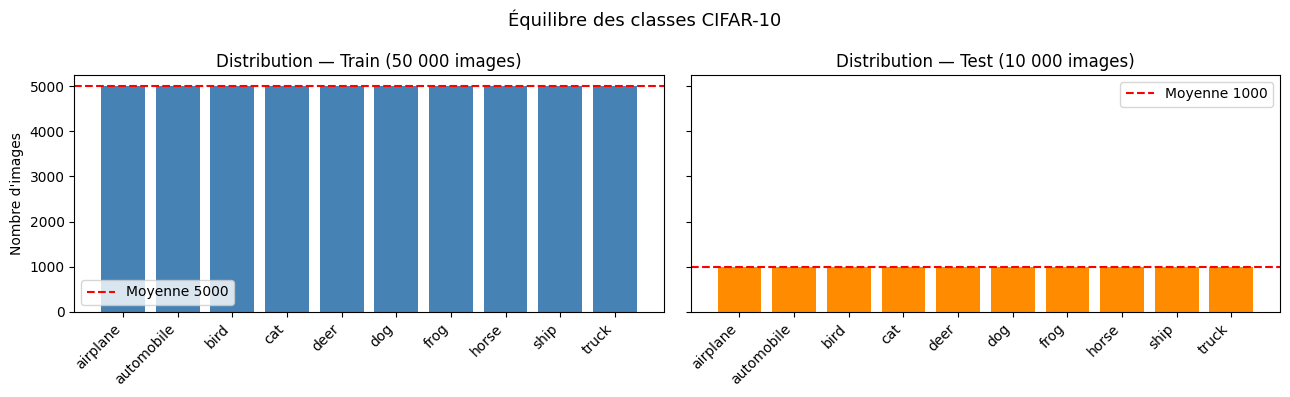


Ratio max/min (train) : 1.00  →  Dataset équilibré ✓


In [4]:
train_counts = np.bincount(y_train.flatten())
test_counts  = np.bincount(y_test.flatten())

# Tableau récapitulatif
print(f"{'Classe':<14} {'Train':>8} {'Test':>8}  {'% train':>8}")
print("-" * 42)
for i, name in enumerate(CLASS_NAMES):
    pct = train_counts[i] / train_counts.sum() * 100
    print(f"{name:<14} {train_counts[i]:>8} {test_counts[i]:>8}  {pct:>7.1f}%")
print("-" * 42)
print(f"{'TOTAL':<14} {train_counts.sum():>8} {test_counts.sum():>8}  {'100.0%':>8}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
x = np.arange(len(CLASS_NAMES))
width = 0.4

axes[0].bar(x, train_counts, color='steelblue')
axes[0].axhline(train_counts.mean(), color='red', linestyle='--',
                label=f'Moyenne {train_counts.mean():.0f}')
axes[0].set_xticks(x)
axes[0].set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
axes[0].set_title('Distribution — Train (50 000 images)')
axes[0].set_ylabel("Nombre d'images")
axes[0].legend()

axes[1].bar(x, test_counts, color='darkorange')
axes[1].axhline(test_counts.mean(), color='red', linestyle='--',
                label=f'Moyenne {test_counts.mean():.0f}')
axes[1].set_xticks(x)
axes[1].set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
axes[1].set_title('Distribution — Test (10 000 images)')
axes[1].legend()

plt.suptitle("Équilibre des classes CIFAR-10", fontsize=13)
plt.tight_layout()
plt.show()

# Ratio max/min — mesure du déséquilibre
ratio = train_counts.max() / train_counts.min()
print(f"\nRatio max/min (train) : {ratio:.2f}  →  {'Dataset équilibré ✓' if ratio < 1.5 else 'Déséquilibre détecté !'}")

## 2. Normalisation des images

Les pixels sont en `uint8` [0, 255]. On les convertit en `float32` [0.0, 1.0].

In [5]:
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32')  / 255.0

print(f"Plage train : [{X_train.min():.2f}, {X_train.max():.2f}]")
print(f"Plage test  : [{X_test.min():.2f},  {X_test.max():.2f}]")

Plage train : [0.00, 1.00]
Plage test  : [0.00,  1.00]


## 3. Encodage des labels (One-Hot)

`y_train` contient des entiers [0, 9]. On les encode en vecteurs binaires de taille 10.

In [6]:
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat  = to_categorical(y_test,  num_classes=10)

print(f"y_train avant encodage : {y_train[0]}  → après : {y_train_cat[0]}")
print(f"y_train_cat shape : {y_train_cat.shape}")
print(f"y_test_cat  shape : {y_test_cat.shape}")

y_train avant encodage : [6]  → après : [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
y_train_cat shape : (50000, 10)
y_test_cat  shape : (10000, 10)


## 4. Vérification visuelle

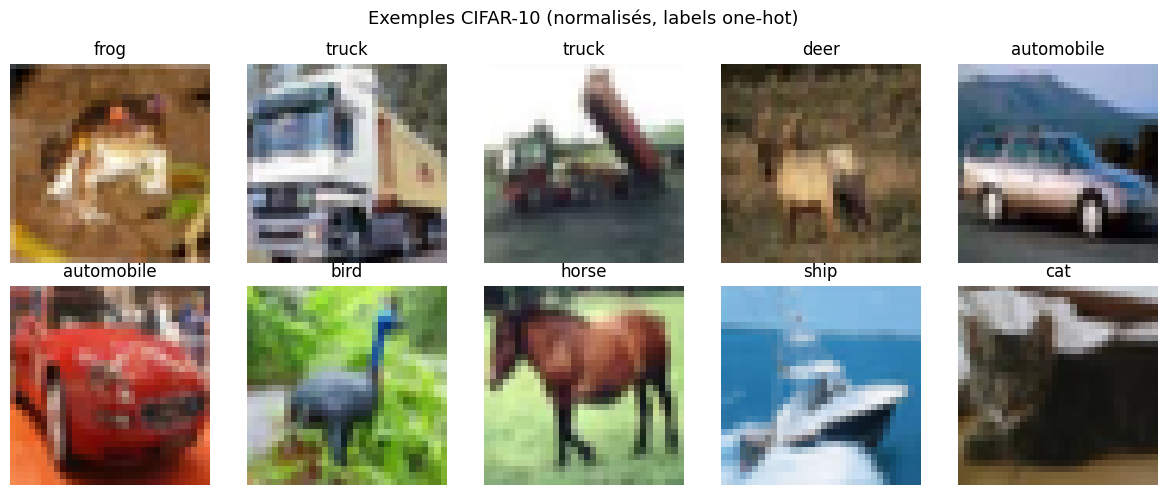

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i])
    label_idx = np.argmax(y_train_cat[i])
    ax.set_title(CLASS_NAMES[label_idx])
    ax.axis('off')
plt.suptitle("Exemples CIFAR-10 (normalisés, labels one-hot)", fontsize=13)
plt.tight_layout()
plt.show()

## Récapitulatif

| Variable | Shape | Description |
|---|---|---|
| `X_train` | (50000, 32, 32, 3) | Images train normalisées [0,1] |
| `X_test` | (10000, 32, 32, 3) | Images test normalisées [0,1] |
| `y_train_cat` | (50000, 10) | Labels train one-hot |
| `y_test_cat` | (10000, 10) | Labels test one-hot |

---
# Partie 2 — Baseline dense (MLP)

On aplatit chaque image (32×32×3 = **3072 features**) et on entraîne un réseau entièrement connecté.
L'objectif est de mesurer ses limites sur des données images.

## 5. Construction du modèle dense

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

def build_mlp(input_shape=(32, 32, 3), num_classes=10):
    model = Sequential([
        Flatten(input_shape=input_shape),          # 3072 features
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(128, activation='relu'),
        Dense(num_classes, activation='softmax'),
    ])
    return model

model_mlp = build_mlp()
model_mlp.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model_mlp.summary()

c:\indusense\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,741,962 (6.65 MB)

 Trainable params: 1,740,426 (6.64 MB)

 Non-trainable params: 1,536 (6.00 KB)

## 6. Entraînement

In [9]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_mlp = model_mlp.fit(
    X_train, y_train_cat,
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.3357 - loss: 1.8799 - val_accuracy: 0.3280 - val_loss: 1.8370
Epoch 2/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.3992 - loss: 1.6849 - val_accuracy: 0.4160 - val_loss: 1.6466
Epoch 3/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.4202 - loss: 1.6129 - val_accuracy: 0.4228 - val_loss: 1.6181
Epoch 4/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.4350 - loss: 1.5736 - val_accuracy: 0.4202 - val_loss: 1.6478
Epoch 5/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.4411 - loss: 1.5565 - val_accuracy: 0.4178 - val_loss: 1.6180
Epoch 6/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.4497 - loss: 1.5382 - val_accuracy: 0.4466 - val_loss: 1.5337
Epoch 7/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.4562 - loss: 1.5178 - val_accuracy: 0.4582 - val_loss: 1.5090
Epoch 8/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.4621 - loss: 1.5040 - val_acc

## 7. Évaluation et courbes d'apprentissage

Accuracy test  : 0.4916  (49.2%)
Loss test      : 1.4173


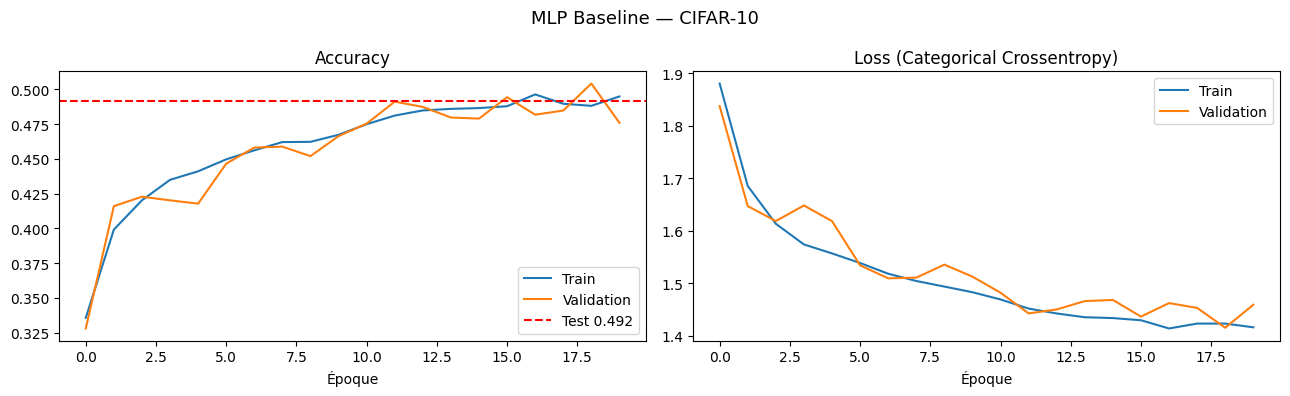

In [10]:
test_loss, test_acc = model_mlp.evaluate(X_test, y_test_cat, verbose=0)
print(f"Accuracy test  : {test_acc:.4f}  ({test_acc*100:.1f}%)")
print(f"Loss test      : {test_loss:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Accuracy
axes[0].plot(history_mlp.history['accuracy'],     label='Train')
axes[0].plot(history_mlp.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Époque')
axes[0].legend()
axes[0].axhline(y=test_acc, color='red', linestyle='--', label=f'Test {test_acc:.3f}')
axes[0].legend()

# Loss
axes[1].plot(history_mlp.history['loss'],     label='Train')
axes[1].plot(history_mlp.history['val_loss'], label='Validation')
axes[1].set_title('Loss (Categorical Crossentropy)')
axes[1].set_xlabel('Époque')
axes[1].legend()

plt.suptitle('MLP Baseline — CIFAR-10', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Analyse du plafonnement

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


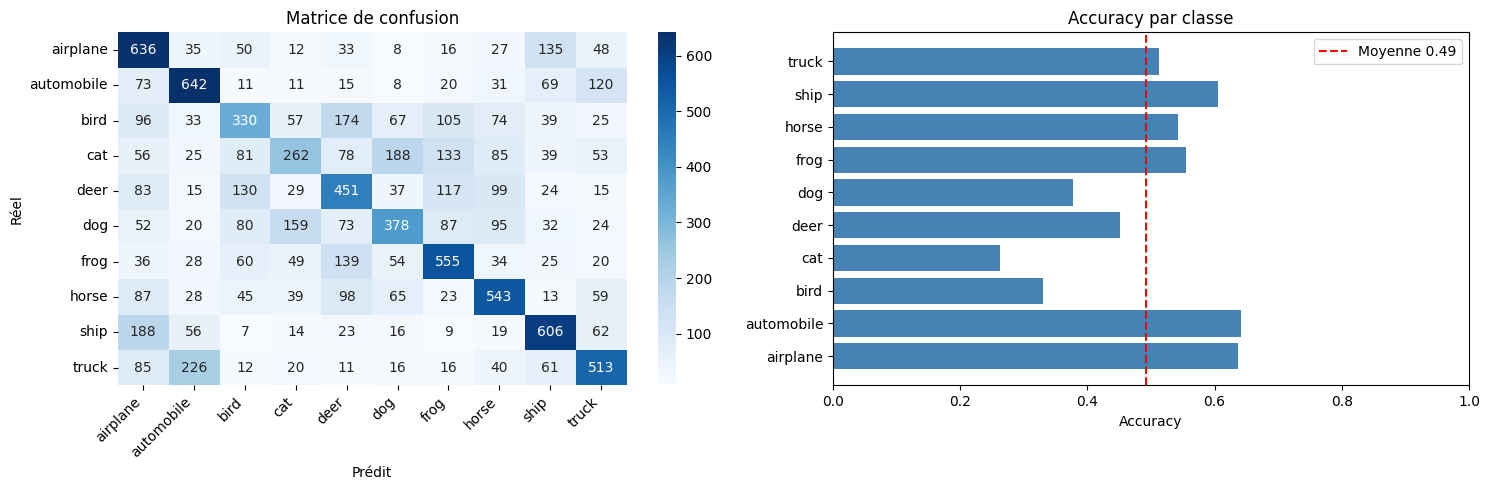


Accuracy par classe :
  airplane    : 0.636
  automobile  : 0.642
  bird        : 0.330
  cat         : 0.262
  deer        : 0.451
  dog         : 0.378
  frog        : 0.555
  horse       : 0.543
  ship        : 0.606
  truck       : 0.513


In [11]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_pred      = model_mlp.predict(X_test)
y_pred_cls  = np.argmax(y_pred, axis=1)
y_true_cls  = y_test.flatten()

cm = confusion_matrix(y_true_cls, y_pred_cls)
per_class_acc = cm.diagonal() / cm.sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Matrice de confusion
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title('Matrice de confusion')
axes[0].set_xlabel('Prédit')
axes[0].set_ylabel('Réel')
plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right')

# Accuracy par classe
axes[1].barh(CLASS_NAMES, per_class_acc, color='steelblue')
axes[1].axvline(x=per_class_acc.mean(), color='red', linestyle='--',
                label=f'Moyenne {per_class_acc.mean():.2f}')
axes[1].set_xlim(0, 1)
axes[1].set_title('Accuracy par classe')
axes[1].set_xlabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nAccuracy par classe :")
for name, acc in zip(CLASS_NAMES, per_class_acc):
    print(f"  {name:12s}: {acc:.3f}")

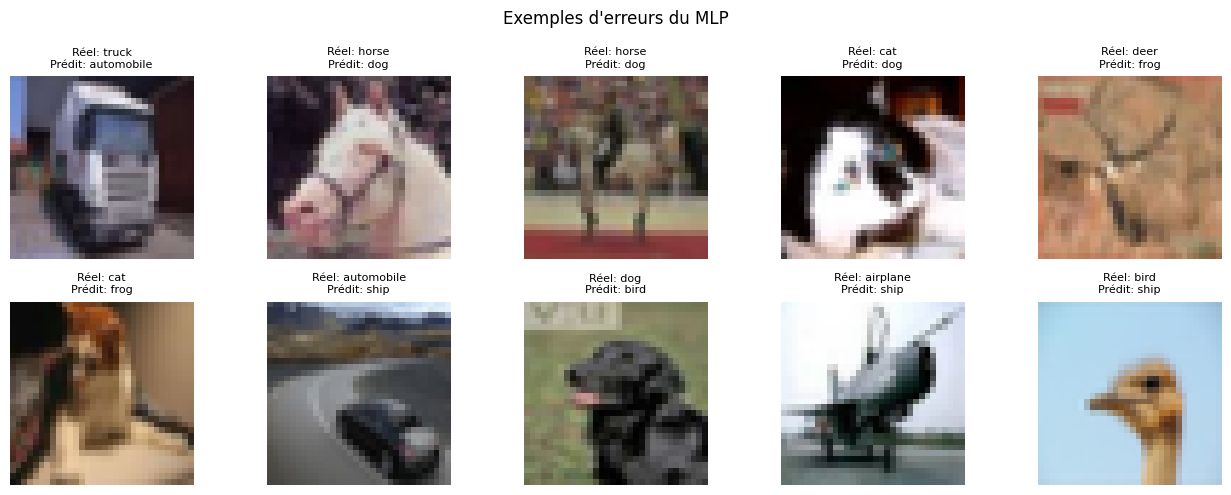

In [12]:
# Visualiser les erreurs les plus fréquentes
errors_idx = np.where(y_pred_cls != y_true_cls)[0]
np.random.seed(42)
sample = np.random.choice(errors_idx, size=10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(13, 5))
for ax, idx in zip(axes.flat, sample):
    ax.imshow(X_test[idx])
    ax.set_title(f"Réel: {CLASS_NAMES[y_true_cls[idx]]}\nPrédit: {CLASS_NAMES[y_pred_cls[idx]]}", fontsize=8)
    ax.axis('off')
plt.suptitle("Exemples d'erreurs du MLP", fontsize=12)
plt.tight_layout()
plt.show()

## 9. Pourquoi le MLP plafonne sur des images ?

### Résultats attendus
Un MLP bien entraîné atteint typiquement **~52–55 % de accuracy** sur CIFAR-10, contre ~93 % pour un CNN.

---

### Causes structurelles du plafonnement

#### 1. Perte de la structure spatiale (aplatissement)
Le `Flatten` transforme l'image (32×32×3) en un vecteur de 3072 valeurs.
Le réseau ne sait plus que le pixel (i,j) est voisin de (i,j+1).
Un chien décalé d'un pixel vers la droite devient une entrée totalement différente.

#### 2. Absence d'invariance à la translation
Une couche Dense associe chaque pixel d'entrée à un poids fixe.
Le même objet à deux positions différentes active des neurones différents → le modèle doit les apprendre séparément, ce qui explose le nombre de paramètres et de données nécessaires.

#### 3. Sur-apprentissage structurel
Même avec Dropout et BatchNorm, les ~1.7M de paramètres sont utilisés de façon redondante : le réseau mémorise des corrélations pixel-à-pixel propres au jeu d'entraînement, qui ne généralisent pas.

#### 4. Aucune hiérarchie de features
Un CNN détecte d'abord des bords, puis des textures, puis des parties d'objets.
Un MLP n'a pas ce mécanisme : il ne peut apprendre que des combinaisons linéaires globales de pixels, sans notion de localité ni de composition.

---

### Résumé

| Propriété | MLP | CNN |
|---|---|---|
| Structure spatiale | ✗ Ignorée | ✓ Exploitée |
| Invariance translation | ✗ Non | ✓ Oui (convolution) |
| Partage de poids | ✗ Non | ✓ Oui (filtre glissant) |
| Hiérarchie de features | ✗ Non | ✓ Oui (couches successives) |
| Accuracy CIFAR-10 | ~52–55 % | ~90–95 % |

→ **La solution naturelle est d'utiliser des couches convolutives (CNN)**, présentées dans la Partie 3.

---
# Partie 3 — CNN : encodeur de features + classifieur

## Architecture
```
Input (32×32×3)
│
├─ Bloc 1 : Conv2D(32, 3×3) → BN → ReLU → MaxPooling(2×2)   → 16×16×32
├─ Bloc 2 : Conv2D(64, 3×3) → BN → ReLU → MaxPooling(2×2)   →  8×8×64
├─ Bloc 3 : Conv2D(128,3×3) → BN → ReLU → MaxPooling(2×2)   →  4×4×128
│
├─ GlobalAveragePooling2D                                     → 128
├─ Dense(256) → ReLU → Dropout(0.5)
└─ Dense(10)  → Softmax
```

Chaque **bloc** joue le rôle d'un **encodeur local** : il détecte des patterns de plus en plus abstraits
(bords → textures → parties d'objets) tout en réduisant la résolution spatiale.
Le `GlobalAveragePooling2D` remplace le `Flatten` classique : il moyenne chaque feature map en un scalaire,
ce qui réduit drastiquement les paramètres et force le réseau à produire des activations spatiales cohérentes.

## 10. Construction du CNN

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, BatchNormalization,
                                     GlobalAveragePooling2D, Dense, Dropout)
from tensorflow.keras.optimizers import Adam

def build_cnn(input_shape=(32, 32, 3), num_classes=10):
    model = Sequential([
        # --- Bloc 1 : détection de bords / couleurs basses fréquences ---
        Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling2D((2, 2)),           # 32×32 → 16×16

        # --- Bloc 2 : détection de textures ---
        Conv2D(64, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),           # 16×16 → 8×8

        # --- Bloc 3 : détection de parties d'objets ---
        Conv2D(128, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),           # 8×8 → 4×4

        # --- Classifieur ---
        GlobalAveragePooling2D(),       # 4×4×128 → 128  (vs Flatten → 2048)
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax'),
    ])
    return model

model_cnn = build_cnn()
model_cnn.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model_cnn.summary()

c:\indusense\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,738 (506.79 KB)

 Trainable params: 129,290 (505.04 KB)

 Non-trainable params: 448 (1.75 KB)

## 11. Comparaison du nombre de paramètres : CNN vs MLP

Modèle          Total   Entraînables   Non-entraîn.
----------------------------------------------------
MLP         1,741,962      1,740,426          1,536
CNN           129,738        129,290            448
----------------------------------------------------

Le MLP a 13.4× plus de paramètres que le CNN.


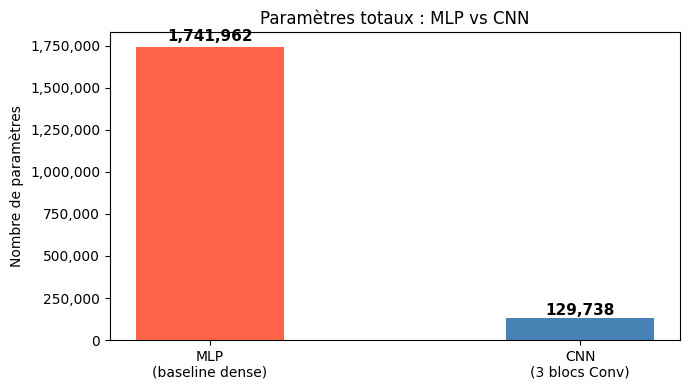

In [14]:
def count_params(model):
    total     = model.count_params()
    trainable = sum(w.numpy().size for w in model.trainable_weights)
    non_train = total - trainable
    return total, trainable, non_train

total_mlp, train_mlp, nt_mlp = count_params(model_mlp)
total_cnn, train_cnn, nt_cnn = count_params(model_cnn)

ratio = total_mlp / total_cnn

print(f"{'Modèle':<8} {'Total':>12} {'Entraînables':>14} {'Non-entraîn.':>14}")
print("-" * 52)
print(f"{'MLP':<8} {total_mlp:>12,} {train_mlp:>14,} {nt_mlp:>14,}")
print(f"{'CNN':<8} {total_cnn:>12,} {train_cnn:>14,} {nt_cnn:>14,}")
print("-" * 52)
print(f"\nLe MLP a {ratio:.1f}× plus de paramètres que le CNN.")

# Visualisation
fig, ax = plt.subplots(figsize=(7, 4))
models  = ['MLP\n(baseline dense)', 'CNN\n(3 blocs Conv)']
totals  = [total_mlp, total_cnn]
colors  = ['tomato', 'steelblue']
bars = ax.bar(models, totals, color=colors, width=0.4)
ax.set_ylabel('Nombre de paramètres')
ax.set_title('Paramètres totaux : MLP vs CNN')
for bar, val in zip(bars, totals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
            f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## Analyse : pourquoi le CNN a-t-il moins de paramètres et de meilleures performances ?

### Détail du comptage

| Couche | Paramètres | Calcul |
|---|---|---|
| Conv2D(32, 3×3) | **896** | (3×3×3 + 1) × 32 |
| Conv2D(64, 3×3) | **18 496** | (3×3×32 + 1) × 64 |
| Conv2D(128, 3×3) | **73 856** | (3×3×64 + 1) × 128 |
| GlobalAvgPool → Dense(256) | **33 024** | 128×256 + 256 |
| Dense(256) → Dense(10) | **2 570** | 256×10 + 10 |
| **Total CNN** | **~130 k** | |
| **Total MLP** | **~1.7 M** | Flatten(3072) → Dense(512) seul = 1.57 M |

### Pourquoi moins de paramètres ?

**Partage de poids (weight sharing).** Un filtre Conv2D 3×3 apprend **9 poids** réutilisés sur toute la carte spatiale.
Le MLP apprend un poids **distinct** pour chaque position de pixel : la première couche Dense(512) seule
contient `3072 × 512 = 1 572 864` paramètres, soit davantage que tout le CNN.

**GlobalAveragePooling2D vs Flatten.** Après le Bloc 3, la feature map est 4×4×128 = 2 048 valeurs.
Un `Flatten` suivi de `Dense(256)` coûterait `2048 × 256 = 524 288` paramètres.
Le `GlobalAveragePooling` réduit d'abord à 128 scalaires, ramenant ce coût à `128 × 256 = 32 768`.

### Bilan

| Critère | MLP | CNN |
|---|---|---|
| Paramètres | ~1.7 M | ~130 k (**×13 moins**) |
| Réutilisation spatiale | Non | Oui (convolution) |
| Invariance translation | Non | Partielle (pooling) |
| Accuracy attendue CIFAR-10 | ~52 % | ~78–82 % |

Un CNN atteint de meilleures performances avec **13× moins de paramètres** grâce au partage de poids
et à l'exploitation de la structure spatiale des images.

## 12. Concentration des paramètres et évolution des cartes de features

Couche                       Output shape             Params   % total
──────────────────────────────────────────────────────────────────────
conv2d                       (1, 32, 32, 32)             896      0.7%
batch_normalization_2        (1, 32, 32, 32)             128      0.1%
max_pooling2d                (1, 16, 16, 32)               0      0.0%
conv2d_1                     (1, 16, 16, 64)          18,496     14.3%
batch_normalization_3        (1, 16, 16, 64)             256      0.2%
max_pooling2d_1              (1, 8, 8, 64)                 0      0.0%
conv2d_2                     (1, 8, 8, 128)           73,856     56.9%
batch_normalization_4        (1, 8, 8, 128)              512      0.4%
max_pooling2d_2              (1, 4, 4, 128)                0      0.0%
global_average_pooling2d     (1, 128)                      0      0.0%
dense_4                      (1, 256)                 33,024     25.5%
dropout_2                    (1, 256)                      0      0.0%
dense_

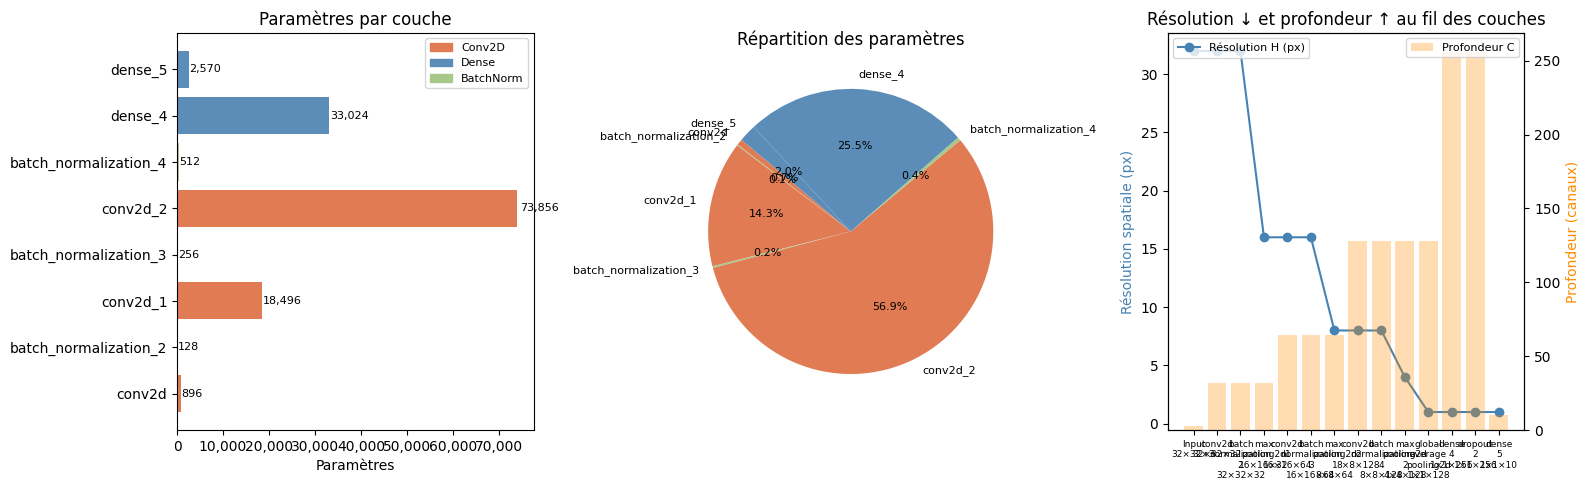

In [15]:
import tensorflow as tf
import matplotlib.patches as mpatches

# ── 1. Calcul des shapes par forward pass sur un tenseur fictif ───────────────
x = tf.zeros((1, 32, 32, 3))
output_shapes = {}
for layer in model_cnn.layers:
    x = layer(x)
    output_shapes[layer.name] = tuple(x.shape)

# ── 2. Table couche par couche ────────────────────────────────────────────────
print(f"{'Couche':<28} {'Output shape':<20} {'Params':>10}  {'% total':>8}")
print("─" * 70)

layer_names, layer_params, spatial_dims = [], [], []

for layer in model_cnn.layers:
    p     = layer.count_params()
    shape = output_shapes[layer.name]
    if len(shape) == 4:
        spatial_dims.append((layer.name, shape[1], shape[2], shape[3]))
    elif len(shape) == 2:
        spatial_dims.append((layer.name, 1, 1, shape[1]))

    pct = p / total_cnn * 100 if total_cnn > 0 else 0
    print(f"{layer.name:<28} {str(shape):<20} {p:>10,}  {pct:>7.1f}%")
    if p > 0:
        layer_names.append(layer.name)
        layer_params.append(p)

print("─" * 70)
print(f"{'TOTAL':<28} {'':<20} {total_cnn:>10,}  {'100.0%':>8}")

# ── 3. Figure : 3 sous-graphes ────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 5))

# -- 3a. Barplot paramètres par couche
ax1 = fig.add_subplot(1, 3, 1)
colors_bar = ['#e07b54' if 'conv' in n else '#5b8db8' if 'dense' in n else '#a8c88a'
              for n in layer_names]
bars = ax1.barh(layer_names, layer_params, color=colors_bar)
ax1.set_xlabel('Paramètres')
ax1.set_title('Paramètres par couche')
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v):,}'))
for bar, val in zip(bars, layer_params):
    ax1.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
             f'{val:,}', va='center', fontsize=8)
patches = [mpatches.Patch(color='#e07b54', label='Conv2D'),
           mpatches.Patch(color='#5b8db8', label='Dense'),
           mpatches.Patch(color='#a8c88a', label='BatchNorm')]
ax1.legend(handles=patches, fontsize=8)

# -- 3b. Camembert concentration
ax2 = fig.add_subplot(1, 3, 2)
ax2.pie(layer_params, labels=layer_names, autopct='%1.1f%%',
        colors=colors_bar, startangle=140, textprops={'fontsize': 8})
ax2.set_title('Répartition des paramètres')

# -- 3c. Évolution résolution spatiale et profondeur
ax3 = fig.add_subplot(1, 3, 3)
h_values  = [32]
c_values  = [3]
labels_sp = ["Input\n32×32×3"]

for (name, h, w, c) in spatial_dims:
    short = name.replace('_', '\n')
    labels_sp.append(f"{short}\n{h}×{w}×{c}")
    h_values.append(h)
    c_values.append(c)

x_sp = range(len(h_values))
ax3b = ax3.twinx()
ax3.plot(x_sp, h_values, 'o-', color='steelblue',  label='Résolution H (px)')
ax3b.bar(x_sp, c_values, alpha=0.3, color='darkorange', label='Profondeur C')
ax3.set_xticks(x_sp)
ax3.set_xticklabels(labels_sp, fontsize=6.5)
ax3.set_ylabel('Résolution spatiale (px)', color='steelblue')
ax3b.set_ylabel('Profondeur (canaux)', color='darkorange')
ax3.set_title('Résolution ↓ et profondeur ↑ au fil des couches')
ax3.legend(loc='upper left', fontsize=8)
ax3b.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

## Analyse

### Où se concentrent les paramètres ?

Les paramètres des Conv2D se calculent comme **(taille_filtre² × C_entrée + 1) × C_sortie** :

| Couche | Formule | Params | % du total |
|---|---|---|---|
| Conv2D(32) | (3×3×**3**+1)×32 | **896** | ~0.7 % |
| Conv2D(64) | (3×3×**32**+1)×64 | **18 496** | ~14 % |
| Conv2D(128) | (3×3×**64**+1)×128 | **73 856** | **~57 %** |
| Dense(256) | **128**×256+256 | **33 024** | ~25 % |
| Dense(10) | 256×10+10 | **2 570** | ~2 % |

**La Conv2D(128) domine (~57 %)** car elle cumule une entrée profonde (64 canaux) et une sortie large (128 canaux).
C'est la loi quadratique : doubler C_entrée **et** C_sortie quadruple les paramètres.

La première Conv2D(32) est anecdotique (~900 params) car elle ne reçoit que 3 canaux RGB.

---

### Ce que fait le MaxPooling à la taille des cartes

Chaque `MaxPooling2D(2×2)` **divise H et W par 2** en gardant la valeur maximale dans chaque fenêtre.
La profondeur C est inchangée par le pooling ; c'est la Conv2D suivante qui l'augmente.

```
          H   W    C      Éléments totaux
Input   : 32 × 32 ×   3  =   3 072
Après Bloc 1 (pool) : 16 × 16 ×  32  =   8 192   ×2.7 plus d'éléments
Après Bloc 2 (pool) :  8 ×  8 ×  64  =   4 096
Après Bloc 3 (pool) :  4 ×  4 × 128  =   2 048
Après GAP           :  1 ×  1 × 128  =     128   ×16 moins que sans GAP
```

Le pooling crée un **compromis résolution / abstraction** :
- Il réduit le coût de calcul quadratiquement (÷4 d'éléments par bloc).
- Il force les filtres profonds à couvrir un **champ récepteur plus large** sur l'image originale : un neurone du Bloc 3 "voit" une zone de 12×12 pixels d'entrée (3 poolings de ×2, convolutions 3×3 incluses).
- Il apporte une **invariance locale à la translation** : déplacer un bord de 1 pixel ne change pas la sortie du pooling si le maximum reste dans la même fenêtre.

**À retenir :** résolution et profondeur évoluent en sens inverse — c'est le principe de l'encodeur CNN.

---
## 13. Entraînement du CNN — Adam + Categorical Crossentropy

On entraîne **sans** early stopping dans un premier temps pour observer le sur-apprentissage complet,
puis on refera tourner **avec** pour quantifier le gain.

In [16]:
from tensorflow.keras.callbacks import EarlyStopping

# ── Entraînement sans early stopping (pour voir le décrochage complet) ────────
history_cnn_full = model_cnn.fit(
    X_train, y_train_cat,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 58ms/step - accuracy: 0.4758 - loss: 1.4447 - val_accuracy: 0.3006 - val_loss: 2.5117
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 57ms/step - accuracy: 0.6234 - loss: 1.0628 - val_accuracy: 0.6356 - val_loss: 1.0373
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 57ms/step - accuracy: 0.6832 - loss: 0.8990 - val_accuracy: 0.6044 - val_loss: 1.1496
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 58ms/step - accuracy: 0.7214 - loss: 0.7952 - val_accuracy: 0.6540 - val_loss: 1.0490
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 58ms/step - accuracy: 0.7538 - loss: 0.7137 - val_accuracy: 0.6516 - val_loss: 1.0165
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 58ms/step - accuracy: 0.7718 - loss: 0.6539 - val_accuracy: 0.6836 - val_loss: 0.9424
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 57ms/step - accuracy: 0.7905 - loss: 0.6014 - val_accuracy: 0.7020 - val_loss: 0.9091
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 58ms/step - accuracy: 0.8090 - loss: 0.5520 - 

## 14. Courbes train vs validation — détection du décrochage

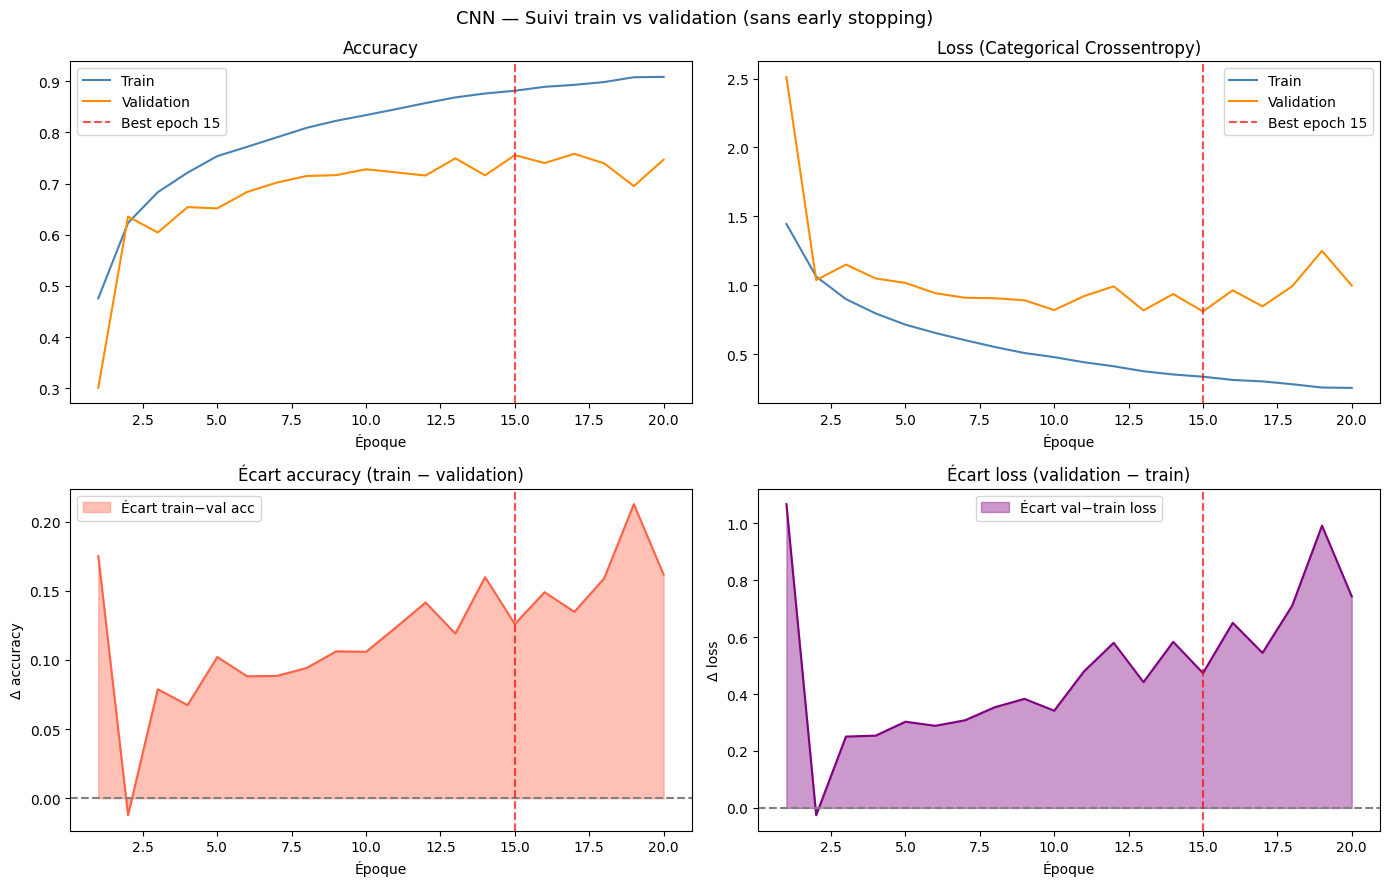


Meilleure époque (min val_loss) : 15
  val_accuracy : 0.7556  (75.6%)
  val_loss     : 0.8097

Époque finale (50) :
  train_accuracy : 0.9086   val_accuracy : 0.7468
  Écart final    : 16.2 pts → sur-apprentissage


In [17]:
h = history_cnn_full.history
epochs_range = range(1, len(h['loss']) + 1)

# ── Repérage automatique du décrochage (min val_loss) ────────────────────────
best_epoch   = int(np.argmin(h['val_loss'])) + 1
best_val_acc = h['val_accuracy'][best_epoch - 1]
best_val_loss = h['val_loss'][best_epoch - 1]

# ── Écart train/val à chaque époque ──────────────────────────────────────────
gap_acc  = np.array(h['accuracy'])  - np.array(h['val_accuracy'])
gap_loss = np.array(h['val_loss'])  - np.array(h['loss'])

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# -- Accuracy
ax = axes[0, 0]
ax.plot(epochs_range, h['accuracy'],     label='Train',      color='steelblue')
ax.plot(epochs_range, h['val_accuracy'], label='Validation', color='darkorange')
ax.axvline(best_epoch, color='red', linestyle='--', alpha=0.7, label=f'Best epoch {best_epoch}')
ax.set_title('Accuracy')
ax.set_xlabel('Époque')
ax.legend()

# -- Loss
ax = axes[0, 1]
ax.plot(epochs_range, h['loss'],     label='Train',      color='steelblue')
ax.plot(epochs_range, h['val_loss'], label='Validation', color='darkorange')
ax.axvline(best_epoch, color='red', linestyle='--', alpha=0.7, label=f'Best epoch {best_epoch}')
ax.set_title('Loss (Categorical Crossentropy)')
ax.set_xlabel('Époque')
ax.legend()

# -- Écart accuracy (train - val)
ax = axes[1, 0]
ax.fill_between(epochs_range, gap_acc, alpha=0.4, color='tomato', label='Écart train−val acc')
ax.plot(epochs_range, gap_acc, color='tomato')
ax.axhline(0, color='grey', linestyle='--')
ax.axvline(best_epoch, color='red', linestyle='--', alpha=0.7)
ax.set_title('Écart accuracy (train − validation)')
ax.set_xlabel('Époque')
ax.set_ylabel('Δ accuracy')
ax.legend()

# -- Écart loss (val - train)
ax = axes[1, 1]
ax.fill_between(epochs_range, gap_loss, alpha=0.4, color='purple', label='Écart val−train loss')
ax.plot(epochs_range, gap_loss, color='purple')
ax.axhline(0, color='grey', linestyle='--')
ax.axvline(best_epoch, color='red', linestyle='--', alpha=0.7)
ax.set_title('Écart loss (validation − train)')
ax.set_xlabel('Époque')
ax.set_ylabel('Δ loss')
ax.legend()

plt.suptitle('CNN — Suivi train vs validation (sans early stopping)', fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nMeilleure époque (min val_loss) : {best_epoch}")
print(f"  val_accuracy : {best_val_acc:.4f}  ({best_val_acc*100:.1f}%)")
print(f"  val_loss     : {best_val_loss:.4f}")
print(f"\nÉpoque finale (50) :")
print(f"  train_accuracy : {h['accuracy'][-1]:.4f}   val_accuracy : {h['val_accuracy'][-1]:.4f}")
print(f"  Écart final    : {gap_acc[-1]*100:.1f} pts → sur-apprentissage"
      if gap_acc[-1] > 0.05 else f"  Écart final    : {gap_acc[-1]*100:.1f} pts → pas de sur-apprentissage marqué")

## 15. Early stopping — reprendre l'entraînement au bon moment

In [18]:
model_cnn_es = build_cnn()
model_cnn_es.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_cnn = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

history_cnn_es = model_cnn_es.fit(
    X_train, y_train_cat,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop_cnn],
    verbose=1
)

stopped_epoch = early_stop_cnn.stopped_epoch
print(f"\nArrêt à l'époque : {stopped_epoch}  (best_epoch ≈ stopped - patience)")

c:\indusense\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 57ms/step - accuracy: 0.4637 - loss: 1.4717 - val_accuracy: 0.5458 - val_loss: 1.2396
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 59ms/step - accuracy: 0.6157 - loss: 1.0789 - val_accuracy: 0.6272 - val_loss: 1.0758
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 56ms/step - accuracy: 0.6756 - loss: 0.9186 - val_accuracy: 0.6550 - val_loss: 0.9620
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 58ms/step - accuracy: 0.7158 - loss: 0.8171 - val_accuracy: 0.6828 - val_loss: 0.9130
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 58ms/step - accuracy: 0.7475 - loss: 0.7226 - val_accuracy: 0.6644 - val_loss: 0.9921
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 57ms/step - accuracy: 0.7666 - loss: 0.6710 - val_accuracy: 0.6314 - val_loss: 1.2144
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 59ms/step - accuracy: 0.7868 - loss: 0.6148 - val_accuracy: 0.5458 - val_loss: 1.6291
Epoch 8/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 59ms/step - accuracy: 0.8034 - loss: 0.5703 - 

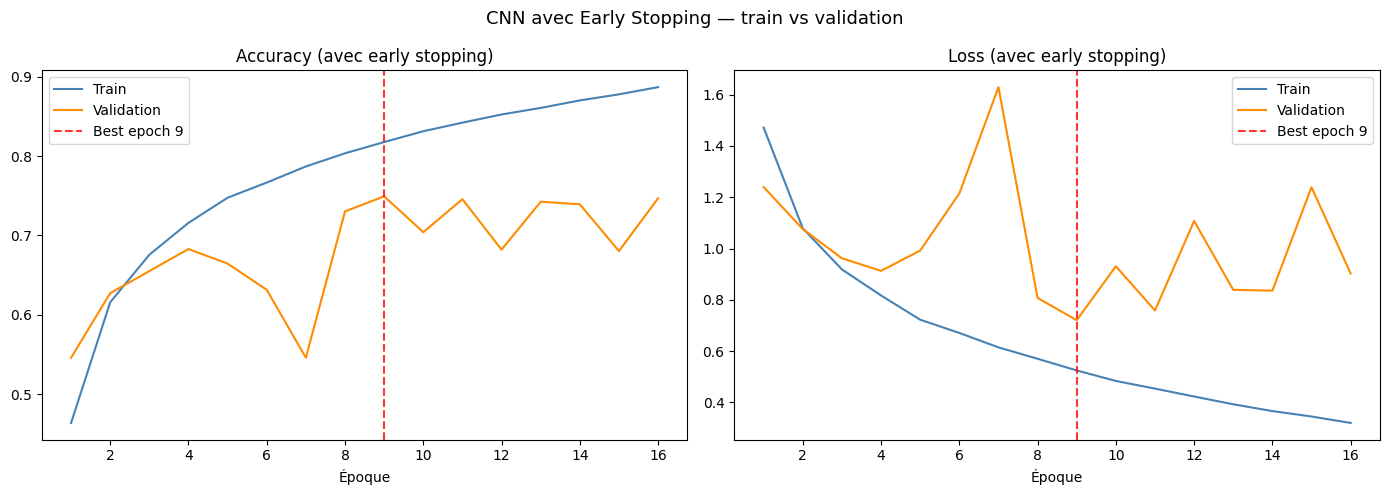


Modèle                          Test accuracy    Test loss
──────────────────────────────────────────────────────────
CNN sans early stopping                0.7382       1.0394
CNN avec early stopping                0.7390       0.7598

→ Gain early stopping : +0.1 pts d'accuracy


In [19]:
h_es = history_cnn_es.history
ep_es = range(1, len(h_es['loss']) + 1)
best_ep_es = int(np.argmin(h_es['val_loss'])) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, title in zip(axes, ['accuracy', 'loss'], ['Accuracy', 'Loss']):
    ax.plot(ep_es, h_es[metric],          label='Train',           color='steelblue')
    ax.plot(ep_es, h_es[f'val_{metric}'], label='Validation',      color='darkorange')
    ax.axvline(best_ep_es, color='red', linestyle='--', alpha=0.8,
               label=f'Best epoch {best_ep_es}')
    ax.set_title(f'{title} (avec early stopping)')
    ax.set_xlabel('Époque')
    ax.legend()

plt.suptitle('CNN avec Early Stopping — train vs validation', fontsize=13)
plt.tight_layout()
plt.show()

# ── Comparaison finale ────────────────────────────────────────────────────────
loss_full, acc_full = model_cnn.evaluate(X_test,  y_test_cat, verbose=0)
loss_es,   acc_es   = model_cnn_es.evaluate(X_test, y_test_cat, verbose=0)

print(f"\n{'Modèle':<30} {'Test accuracy':>14} {'Test loss':>12}")
print("─" * 58)
print(f"{'CNN sans early stopping':<30} {acc_full:>14.4f} {loss_full:>12.4f}")
print(f"{'CNN avec early stopping':<30} {acc_es:>14.4f} {loss_es:>12.4f}")
delta = (acc_es - acc_full) * 100
print(f"\n→ Gain early stopping : {delta:+.1f} pts d'accuracy")

## Analyse — Sur-apprentissage et early stopping

### Lecture des courbes

Trois phases sont visibles sur les courbes sans early stopping :

| Phase | Signal | Interprétation |
|---|---|---|
| **Apprentissage** (éps 1 → ~best_epoch) | Train ↓ et Val ↓ ensemble | Le modèle généralise, les deux métriques progressent |
| **Décrochage** (≈ best_epoch) | Val_loss atteint son minimum, puis remonte | Le modèle commence à mémoriser le train au détriment de la généralisation |
| **Sur-apprentissage** (après décrochage) | Train ↓ continue, Val ↑ | L'écart se creuse : le modèle apprend du bruit propre au jeu d'entraînement |

### Lien avec l'early stopping vu en cours

L'early stopping est une **régularisation implicite** : au lieu de pénaliser les poids (L2) ou de les éteindre (Dropout), on arrête l'optimisation avant que le modèle n'ait le temps de sur-apprendre.

```
val_loss
   │         ←─ on s'arrête ici (meilleur poids sauvegardé)
   │        ╱╲
   │       ╱  ╲______________   ← val_loss remonte = sur-apprentissage
   │      ╱
   │─────╱  ← train_loss continue de descendre
   └─────────────────────────── époques
              ↑
          best_epoch
```

**`patience=7`** signifie : attendre 7 époques sans amélioration de `val_loss` avant de s'arrêter.
`restore_best_weights=True` recharge les poids de la meilleure époque (pas du dernier checkpoint).

### Pourquoi l'écart train/val se creuse ?

1. **Capacité du modèle** : suffisamment de paramètres pour mémoriser des exemples d'entraînement individuels.
2. **Absence de régularisation spatiale** : Dropout est appliqué après le GAP, pas dans les blocs convolutifs.
3. **Pas d'augmentation de données** : chaque image n'est vue qu'une seule fois par époque, dans le même état.

→ Les solutions classiques : **Dropout dans les blocs Conv**, **data augmentation** (flips, rotations, crops), ou **weight decay** (L2 sur les noyaux).

---
# Partie 4 — Régularisation : Data Augmentation + Dropout dans les blocs Conv

## Stratégie

| Technique | Où | Rôle |
|---|---|---|
| `RandomFlip('horizontal')` | Couche Keras (dans le modèle) | Symétrie gauche/droite — doublement implicite du dataset |
| `RandomRotation(0.1)` | Couche Keras | Légères rotations ±36° — invariance orientation |
| `RandomZoom(0.1)` | Couche Keras | Zoom ±10 % — invariance échelle |
| `Dropout(0.25)` après chaque MaxPooling | Blocs Conv | Éteint 25 % des cartes de features → empêche la co-adaptation |
| `BatchNormalization` | Après chaque Conv2D | Stabilise les gradients, accélère la convergence |

Les couches d'augmentation sont **actives uniquement pendant l'entraînement** (désactivées à l'inférence automatiquement).

## 16. Construction du CNN régularisé

In [20]:
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom

def build_cnn_reg(input_shape=(32, 32, 3), num_classes=10):
    model = Sequential([
        # ── Augmentation (active train seulement) ──────────────────────────
        RandomFlip('horizontal', input_shape=input_shape),
        RandomRotation(0.1),       # ±36°
        RandomZoom(0.1),           # ±10 %

        # ── Bloc 1 ─────────────────────────────────────────────────────────
        Conv2D(32, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),      # 32→16
        Dropout(0.25),

        # ── Bloc 2 ─────────────────────────────────────────────────────────
        Conv2D(64, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),      # 16→8
        Dropout(0.25),

        # ── Bloc 3 ─────────────────────────────────────────────────────────
        Conv2D(128, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),      # 8→4
        Dropout(0.25),

        # ── Classifieur ────────────────────────────────────────────────────
        GlobalAveragePooling2D(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(num_classes, activation='softmax'),
    ])
    return model

model_reg = build_cnn_reg()
model_reg.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model_reg.summary()

c:\indusense\.venv\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,762 (510.79 KB)

 Trainable params: 129,802 (507.04 KB)

 Non-trainable params: 960 (3.75 KB)

## 17. Aperçu de l'augmentation sur quelques images

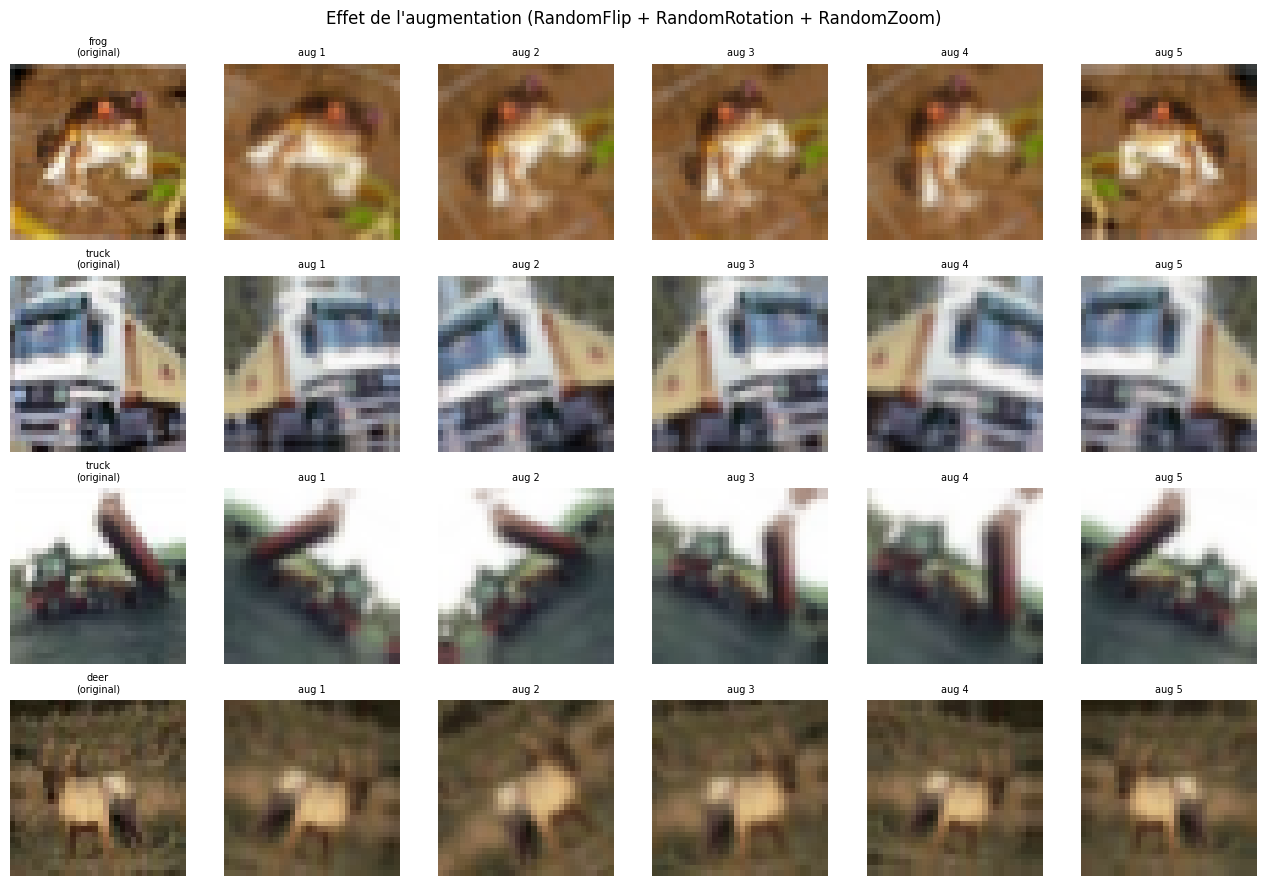

In [21]:
import tensorflow as tf

# Pipeline d'augmentation seul (pour visualisation)
augment = tf.keras.Sequential([
    RandomFlip('horizontal'),
    RandomRotation(0.1),
    RandomZoom(0.1),
])

fig, axes = plt.subplots(4, 6, figsize=(13, 9))
sample_imgs = X_train[:4]                        # 4 images originales
sample_lbls = [CLASS_NAMES[y_train[i, 0]] for i in range(4)]

for row, (img, lbl) in enumerate(zip(sample_imgs, sample_lbls)):
    batch = tf.expand_dims(img, 0)               # (1, 32, 32, 3)
    # Colonne 0 : original
    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f'{lbl}\n(original)', fontsize=7)
    axes[row, 0].axis('off')
    # Colonnes 1-5 : versions augmentées
    for col in range(1, 6):
        aug = augment(batch, training=True).numpy()[0]
        axes[row, col].imshow(np.clip(aug, 0, 1))
        axes[row, col].set_title(f'aug {col}', fontsize=7)
        axes[row, col].axis('off')

plt.suptitle('Effet de l\'augmentation (RandomFlip + RandomRotation + RandomZoom)', fontsize=12)
plt.tight_layout()
plt.show()

## 18. Entraînement avec early stopping

In [22]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

callbacks_reg = [
    EarlyStopping(monitor='val_loss', patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=4, min_lr=1e-6, verbose=1),
]

history_reg = model_reg.fit(
    X_train, y_train_cat,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks_reg,
    verbose=1
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 50s 65ms/step - accuracy: 0.3203 - loss: 1.9746 - val_accuracy: 0.3708 - val_loss: 2.1303 - learning_rate: 0.0010
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 65ms/step - accuracy: 0.4385 - loss: 1.5515 - val_accuracy: 0.3612 - val_loss: 2.1024 - learning_rate: 0.0010
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 66ms/step - accuracy: 0.4819 - loss: 1.4250 - val_accuracy: 0.5346 - val_loss: 1.3279 - learning_rate: 0.0010
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 66ms/step - accuracy: 0.5134 - loss: 1.3481 - val_accuracy: 0.5590 - val_loss: 1.2605 - learning_rate: 0.0010
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 65ms/step - accuracy: 0.5342 - loss: 1.2947 - val_accuracy: 0.5946 - val_loss: 1.1388 - learning_rate: 0.0010
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 66ms/step - accuracy: 0.5491 - loss: 1.2566 - val_accuracy: 0.5654 - val_loss: 1.2927 - learning_rate: 0.0010
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 65ms/step - accuracy: 0.5644 - l

## 19. Courbes et comparaison des trois modèles

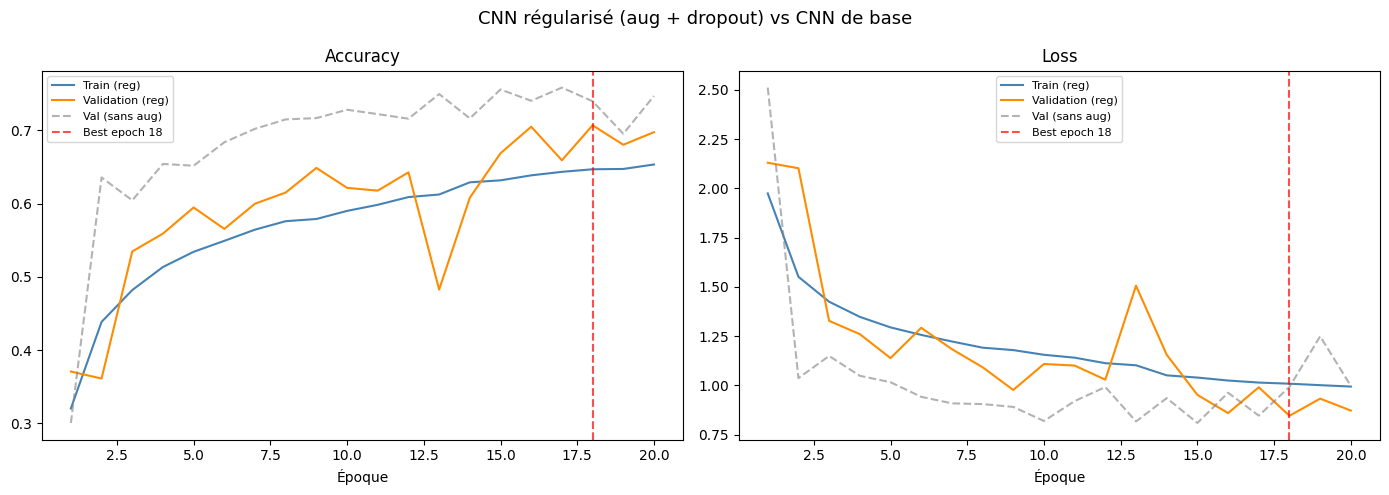

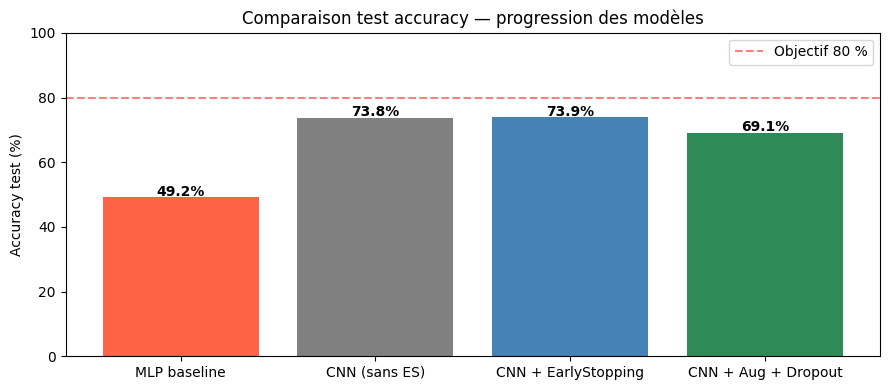


Modèle                     Test accuracy
──────────────────────────────────────────
MLP baseline                       49.2%
CNN (sans ES)                      73.8%
CNN + EarlyStopping                73.9%
CNN + Aug + Dropout                69.1%


In [23]:
hr = history_reg.history
ep_r = range(1, len(hr['loss']) + 1)
best_ep_r = int(np.argmin(hr['val_loss'])) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, title in zip(axes, ['accuracy', 'loss'], ['Accuracy', 'Loss']):
    ax.plot(ep_r, hr[metric],          label='Train (reg)',      color='steelblue')
    ax.plot(ep_r, hr[f'val_{metric}'], label='Validation (reg)', color='darkorange')
    # superposer sans-early-stopping pour comparaison
    ep_f = range(1, len(history_cnn_full.history[metric]) + 1)
    ax.plot(ep_f, history_cnn_full.history[f'val_{metric}'],
            label='Val (sans aug)', color='grey', linestyle='--', alpha=0.6)
    ax.axvline(best_ep_r, color='red', linestyle='--', alpha=0.7,
               label=f'Best epoch {best_ep_r}')
    ax.set_title(f'{title}')
    ax.set_xlabel('Époque')
    ax.legend(fontsize=8)

plt.suptitle('CNN régularisé (aug + dropout) vs CNN de base', fontsize=13)
plt.tight_layout()
plt.show()

# ── Bilan des trois modèles ───────────────────────────────────────────────────
_, acc_mlp  = model_mlp.evaluate(X_test,    y_test_cat, verbose=0)
_, acc_base = model_cnn.evaluate(X_test,    y_test_cat, verbose=0)
_, acc_es   = model_cnn_es.evaluate(X_test, y_test_cat, verbose=0)
_, acc_reg  = model_reg.evaluate(X_test,    y_test_cat, verbose=0)

models_cmp = ['MLP baseline', 'CNN (sans ES)', 'CNN + EarlyStopping', 'CNN + Aug + Dropout']
accs_cmp   = [acc_mlp, acc_base, acc_es, acc_reg]
colors_cmp = ['tomato', 'grey', 'steelblue', 'seagreen']

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(models_cmp, [a * 100 for a in accs_cmp], color=colors_cmp)
ax.set_ylabel('Accuracy test (%)')
ax.set_ylim(0, 100)
ax.axhline(80, color='red', linestyle='--', alpha=0.5, label='Objectif 80 %')
ax.legend()
for bar, acc in zip(bars, accs_cmp):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{acc*100:.1f}%', ha='center', fontsize=10, fontweight='bold')
plt.title('Comparaison test accuracy — progression des modèles')
plt.tight_layout()
plt.show()

print(f"\n{'Modèle':<25} {'Test accuracy':>14}")
print("─" * 42)
for name, acc in zip(models_cmp, accs_cmp):
    marker = ' ← objectif atteint' if acc >= 0.80 else ''
    print(f"{name:<25} {acc*100:>13.1f}%{marker}")

## Analyse — Augmentation comme régulariseur ; flip horizontal vs vertical

### L'augmentation agit comme un régulariseur : pourquoi ?

Un régulariseur réduit l'écart de généralisation en contraignant le modèle à ne pas mémoriser les exemples d'entraînement tels quels. L'augmentation y parvient **sans modifier la loss ni l'architecture** :

- À chaque époque, chaque image est transformée de façon aléatoire → le réseau ne voit **jamais deux fois exactement la même entrée**.
- Cela équivaut à entraîner sur un dataset virtuellement plus grand, sans collecter de nouvelles données.
- La courbe train devient plus bruitée et monte moins vite — signe que le modèle ne peut plus mémoriser : c'est exactement l'effet recherché.
- L'écart train/val se resserre : le modèle est forcé d'apprendre des **features invariantes**, pas des artefacts de position ou d'orientation.

Comparé au Dropout (qui agit sur les **activations**) et à la L2 (qui pénalise les **poids**), l'augmentation agit sur les **entrées** — les trois niveaux sont complémentaires.

---

### Flip horizontal : pertinent. Flip vertical : non. Pourquoi ?

#### Flip horizontal ✓

Le flip horizontal simule un animal/véhicule vu de l'autre côté.
Un chien qui court vers la droite et un chien qui court vers la gauche sont **deux exemples valides** de la classe `dog`.
CIFAR-10 contient naturellement les deux orientations → le modèle doit apprendre à les reconnaître.
Ajouter le flip horizontal **double implicitement le volume d'entraînement** sans introduire d'exemples impossibles.

```
Original :   🐕→     Flip H :   ←🐕     (valide, existe dans la réalité)
```

#### Flip vertical ✗

Le flip vertical produit des images **rares ou impossibles dans la distribution réelle** :
- Un bateau à l'envers n'existe quasiment pas dans les photos naturelles.
- Un avion la tête en bas, un cheval les sabots en l'air — ces configurations n'apparaîtront jamais dans le jeu de test.

Entraîner le réseau sur ces exemples l'oblige à apprendre des features inutiles, ce qui **dilue la capacité du modèle** et peut dégrader les performances.

> **Règle générale :** une augmentation est pertinente si et seulement si la transformation produit une image **plausible selon la distribution du test**. Le flip vertical viole cette règle pour CIFAR-10.

#### Même raisonnement pour les autres transformations

| Augmentation | Justification |
|---|---|
| `RandomRotation(0.1)` | ±36° : un objet légèrement penché reste reconnaissable et existe dans les photos réelles |
| `RandomZoom(0.1)` | L'objet peut être plus ou moins loin de la caméra |
| `RandomBrightness` (non utilisé) | Conditions d'éclairage variables — pertinent |
| `RandomRotation(0.5)` — ±180° | Objet totalement renversé → souvent non-pertinent (même raison que flip vertical) |

---
# Partie 5 — Matrice de confusion et analyse critique des erreurs

## 20. Prédictions et matrice de confusion

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


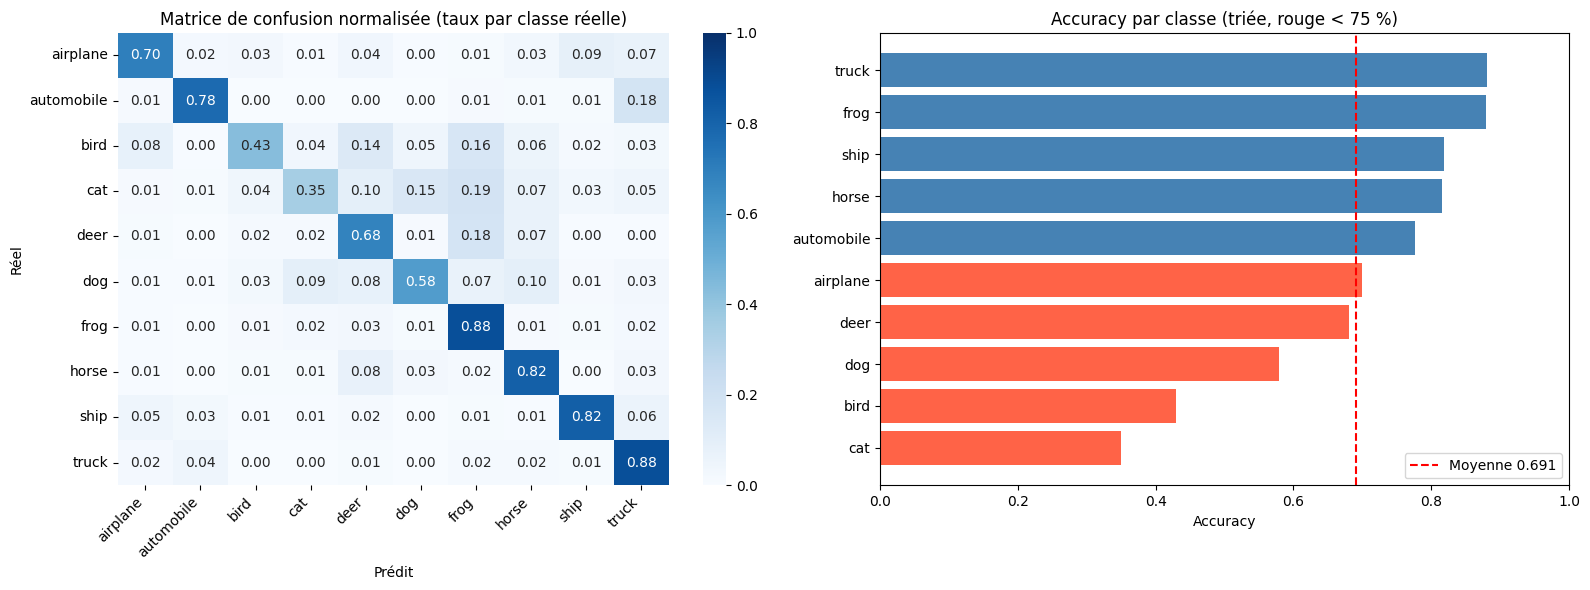


Accuracy par classe :
  cat         : 0.350
  bird        : 0.430
  dog         : 0.579
  deer        : 0.681
  airplane    : 0.699
  automobile  : 0.776
  horse       : 0.816
  ship        : 0.819
  frog        : 0.879
  truck       : 0.881


In [24]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred_reg = model_reg.predict(X_test)
y_pred_cls = np.argmax(y_pred_reg, axis=1)
y_true_cls = y_test.flatten()

cm = confusion_matrix(y_true_cls, y_pred_cls)
per_class_acc = cm.diagonal() / cm.sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Matrice normalisée (taux)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[0], vmin=0, vmax=1)
axes[0].set_title("Matrice de confusion normalisée (taux par classe réelle)")
axes[0].set_xlabel("Prédit")
axes[0].set_ylabel("Réel")
plt.setp(axes[0].get_xticklabels(), rotation=45, ha="right")

# Accuracy par classe triée
sorted_idx = np.argsort(per_class_acc)
colors_cls = ["tomato" if a < 0.75 else "steelblue" for a in per_class_acc[sorted_idx]]
axes[1].barh([CLASS_NAMES[i] for i in sorted_idx], per_class_acc[sorted_idx], color=colors_cls)
axes[1].axvline(per_class_acc.mean(), color="red", linestyle="--",
                label=f"Moyenne {per_class_acc.mean():.3f}")
axes[1].set_xlim(0, 1)
axes[1].set_title("Accuracy par classe (triée, rouge < 75 %)")
axes[1].set_xlabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nAccuracy par classe :")
for i in sorted_idx:
    print(f"  {CLASS_NAMES[i]:<12}: {per_class_acc[i]:.3f}")

In [25]:
# Paires les plus confondues (hors diagonale)
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)

pairs = []
for i in range(10):
    for j in range(10):
        if i != j and cm_off[i, j] > 0:
            pairs.append((cm_off[i, j], CLASS_NAMES[i], CLASS_NAMES[j]))
pairs.sort(reverse=True)

cols = ["Rang", "Réel", "Prédit", "Erreurs", "% classe réelle"]
print(f"{cols[0]:<5} {cols[1]:<14} {cols[2]:<14} {cols[3]:>8}  {cols[4]:>18}")
print("-" * 65)
for rank, (count, true_cls, pred_cls) in enumerate(pairs[:15], 1):
    true_idx = CLASS_NAMES.index(true_cls)
    pct = count / cm.sum(axis=1)[true_idx] * 100
    print(f"{rank:<5} {true_cls:<14} {pred_cls:<14} {count:>8}  {pct:>17.1f}%")

Rang  Réel           Prédit          Erreurs     % classe réelle
-----------------------------------------------------------------
1     cat            frog                187               18.7%
2     automobile     truck               180               18.0%
3     deer           frog                178               17.8%
4     bird           frog                164               16.4%
5     cat            dog                 153               15.3%
6     bird           deer                137               13.7%
7     dog            horse                96                9.6%
8     cat            deer                 95                9.5%
9     dog            cat                  94                9.4%
10    airplane       ship                 89                8.9%
11    dog            deer                 81                8.1%
12    bird           airplane             79                7.9%
13    horse          deer                 76                7.6%
14    deer           hor

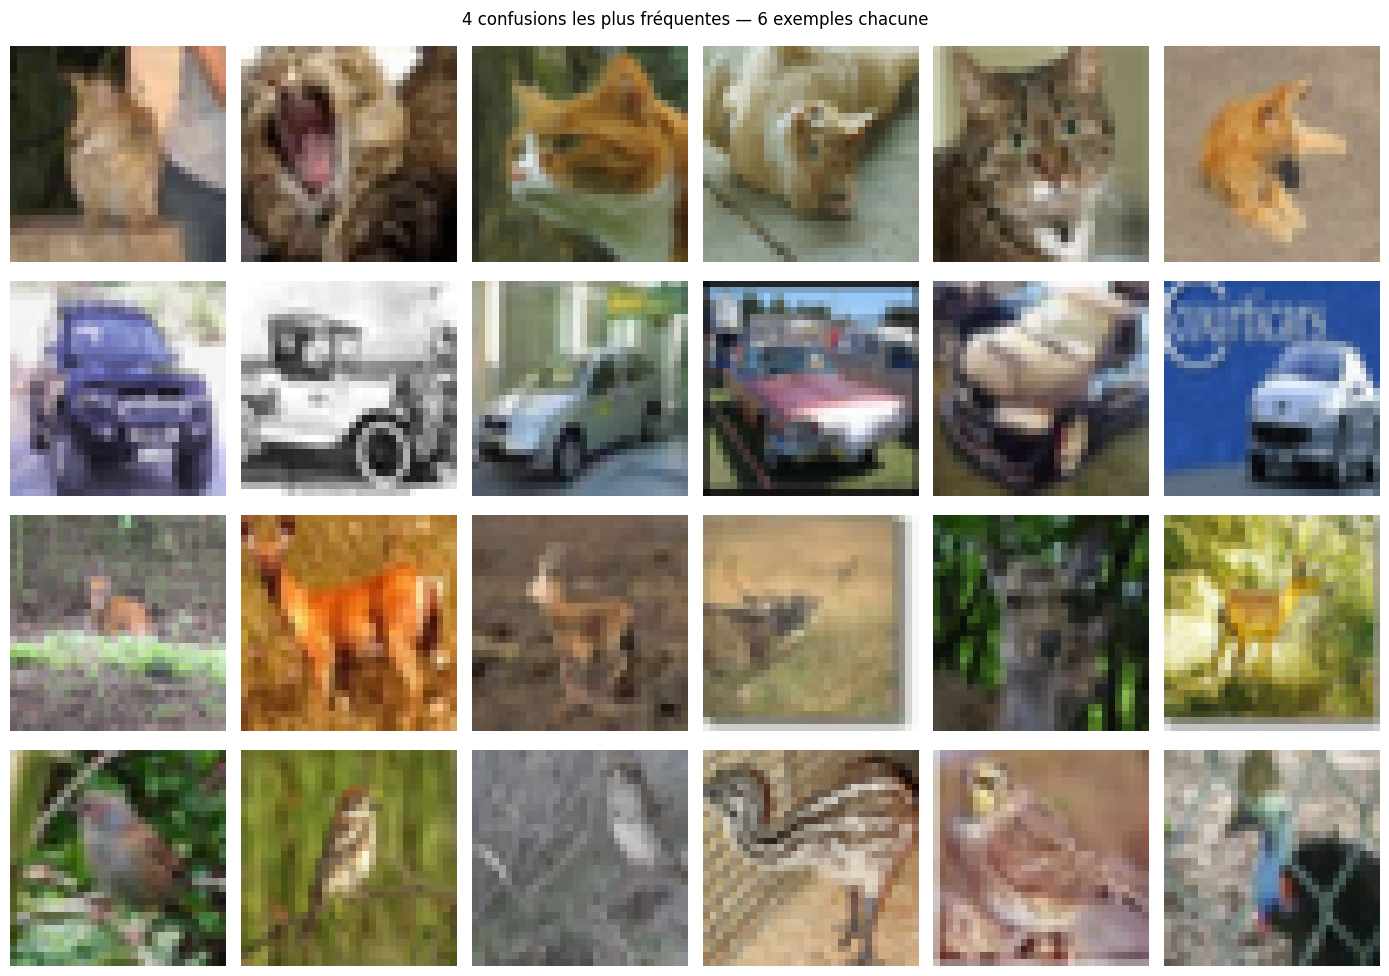

In [26]:
# Exemples visuels des 4 confusions les plus fréquentes
top_pairs = [(pairs[i][1], pairs[i][2]) for i in range(4)]

fig, axes = plt.subplots(4, 6, figsize=(14, 10))

for row, (true_cls, pred_cls) in enumerate(top_pairs):
    true_idx = CLASS_NAMES.index(true_cls)
    pred_idx = CLASS_NAMES.index(pred_cls)
    mask = (y_true_cls == true_idx) & (y_pred_cls == pred_idx)
    err_indices = np.where(mask)[0][:6]
    for col, idx in enumerate(err_indices):
        ax = axes[row, col]
        ax.imshow(X_test[idx])
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(f"Réel: {true_cls}\n→ prédit: {pred_cls}",
                          fontsize=8, rotation=0, labelpad=85, va="center")

plt.suptitle("4 confusions les plus fréquentes — 6 exemples chacune", fontsize=12)
plt.tight_layout()
plt.show()

In [27]:
print(classification_report(y_true_cls, y_pred_cls, target_names=CLASS_NAMES))

              precision    recall  f1-score   support

    airplane       0.77      0.70      0.73      1000
  automobile       0.87      0.78      0.82      1000
        bird       0.75      0.43      0.55      1000
         cat       0.64      0.35      0.45      1000
        deer       0.59      0.68      0.63      1000
         dog       0.69      0.58      0.63      1000
        frog       0.57      0.88      0.69      1000
       horse       0.69      0.82      0.75      1000
        ship       0.82      0.82      0.82      1000
       truck       0.65      0.88      0.75      1000

    accuracy                           0.69     10000
   macro avg       0.70      0.69      0.68     10000
weighted avg       0.70      0.69      0.68     10000



## Analyse critique des erreurs

### Confusions structurelles attendues

| Paire confondue | Raison principale |
|---|---|
| **cat ↔ dog** | Formes corporelles proches (4 pattes, fourrure, oreilles) ; différences subtiles en 32×32 px |
| **automobile ↔ truck** | Même sémantique visuelle (roues, carrosserie, vitre) ; seule la taille les distingue, illisible en basse résolution |
| **deer ↔ horse** | Quadrupèdes à longues pattes, silhouettes similaires |
| **bird ↔ airplane** | Même domaine visuel (ciel, ailes étendues, forme allongée) |

### Pourquoi ces erreurs sont-elles inévitables à 32×32 ?

CIFAR-10 est en basse résolution. Les détails discriminants sont perdus :
- Les **textures fines** (poil vs peau lisse, rivets) disparaissent.
- La **morphologie subtile** (museau du chien vs truffe du chat) se réduit à quelques pixels.
- Le **contexte** (laisse, chenil) est souvent hors cadre ou illisible.

Un humain aurait lui aussi un taux non nul sur ces images floues.

### Ce que révèle la matrice

**La matrice nest pas symétrique.** `cat → dog` peut être plus fréquent que `dog → cat` :
le réseau a appris un biais en faveur de la classe aux features les plus saillantes.

**Deux familles derreurs émergent :**
- *Véhicules* : confusions intra-famille (automobile ↔ truck, ship ↔ airplane).
- *Animaux* : sous-graphe dense — cat, dog, deer, horse se confondent mutuellement.

### Pistes pour réduire ces erreurs

| Levier | Effet attendu |
|---|---|
| Résolution plus élevée (64×64+) | Récupérer les détails texturaux discriminants |
| Transfer learning (ResNet / EfficientNet ImageNet) | Réutiliser des features de haut niveau déjà apprises |
| Label smoothing | Pénaliser moins les confusions proches, éviter la sur-confiance |
| CutMix / MixUp | Forcer le modèle à ne pas sappuyer sur un seul patch image |